In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-meas',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_meas',
        '--data_nsample', '144',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '128',
        '--nlayer_stat', '3',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.793039, valid=0.526590, test=0.556040
	validation loss decreased (inf -> 0.526590), saving model ...
	epoch 2 losses: train=1.690730, valid=0.510071, test=0.534421
	validation loss decreased (0.526590 -> 0.510071), saving model ...
	epoch 3 losses: train=1.242754, valid=0.299525, test=0.313087
	validation loss decreased (0.510071 -> 0.299525), saving model ...
	epoch 4 losses: train=0.835973, valid=0.253095, test=0.279962
	validation loss decreased (0.299525 -> 0.253095), saving model ...
	epoch 5 losses: train=0.805780, valid=0.249614, test=0.276452
	validation loss decreased (0.253095 -> 0.249614), saving model ...
	epoch 6 losses: train=0.796805, valid=0.249364, test=0.275439
	validation loss decreased (0.249614 -> 0.249364), saving model ...
	epoch 7 losses: train=0.794425, valid=0.247471, test=0.276183
	validation loss decreased (0.249364 -> 0.247471), saving model ...
	epoch 8 losses: train=0.791521, valid=0.249257, test=0.27

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

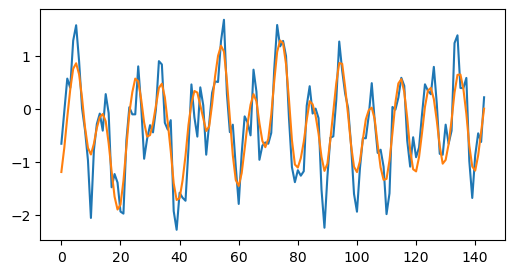

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.501688, valid=0.568958, test=0.377559
	validation loss decreased (inf -> 0.568958), saving model ...
	epoch 2 losses: train=0.393486, valid=0.476348, test=0.263167
	validation loss decreased (0.568958 -> 0.476348), saving model ...
	epoch 3 losses: train=0.338766, valid=0.453880, test=0.244983
	validation loss decreased (0.476348 -> 0.453880), saving model ...
	epoch 4 losses: train=0.323974, valid=0.435281, test=0.246591
	validation loss decreased (0.453880 -> 0.435281), saving model ...
	epoch 5 losses: train=0.322620, valid=0.436668, test=0.245771
	early stopping counter: 1 out of 30
	epoch 6 losses: train=0.318112, valid=0.427912, test=0.238272
	validation loss decreased (0.435281 -> 0.427912), saving model ...
	epoch 7 losses: train=0.316890, valid=0.433087, test=0.245054
	early stopping counter: 1 out of 30
	epoch 8 losses: train=0.312958, valid=0.422764, test=0.244842
	validation loss decreased (0.427912 -> 0.422764),

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

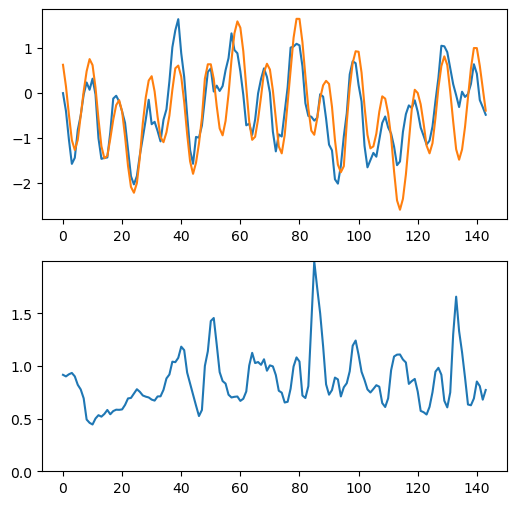

In [9]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.347553, valid=0.687018, test=0.668152
	validation loss decreased (inf -> 0.687018), saving model ...
	epoch 2 losses: train=0.736421, valid=0.465065, test=0.455632
	validation loss decreased (0.687018 -> 0.465065), saving model ...
	epoch 3 losses: train=0.560910, valid=0.341462, test=0.329033
	validation loss decreased (0.465065 -> 0.341462), saving model ...
	epoch 4 losses: train=0.415279, valid=0.290330, test=0.278862
	validation loss decreased (0.341462 -> 0.290330), saving model ...
	epoch 5 losses: train=0.368950, valid=0.270236, test=0.258329
	validation loss decreased (0.290330 -> 0.270236), saving model ...
	epoch 6 losses: train=0.344996, valid=0.265732, test=0.248898
	validation loss decreased (0.270236 -> 0.265732), saving model ...
	epoch 7 losses: train=0.332109, valid=0.270767, test=0.259083
	early stopping counter: 1 out of 30
	epoch 8 losses: train=0.322895, valid=0.253199, test=0.242408
	validation loss decreased 

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

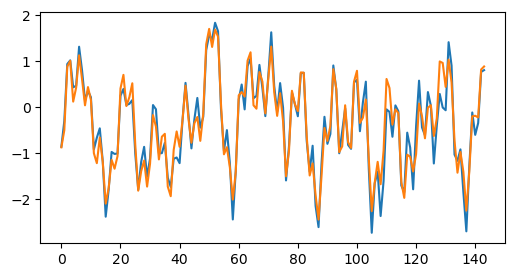

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.548450, valid=0.016901, test=0.249179
	validation loss decreased (inf -> 0.016901), saving model ...
	epoch 2 losses: train=0.073928, valid=-0.014710, test=0.147666
	validation loss decreased (0.016901 -> -0.014710), saving model ...
	epoch 3 losses: train=-0.013956, valid=-0.046358, test=0.111946
	validation loss decreased (-0.014710 -> -0.046358), saving model ...
	epoch 4 losses: train=-0.053733, valid=-0.078832, test=0.075648
	validation loss decreased (-0.046358 -> -0.078832), saving model ...
	epoch 5 losses: train=-0.101331, valid=-0.108051, test=0.038364
	validation loss decreased (-0.078832 -> -0.108051), saving model ...
	epoch 6 losses: train=-0.168334, valid=-0.172071, test=-0.023686
	validation loss decreased (-0.108051 -> -0.172071), saving model ...
	epoch 7 losses: train=-0.199544, valid=-0.184096, test=-0.021234
	validation loss decreased (-0.172071 -> -0.184096), saving model ...
	epoch 8 losses: train=-0.04

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

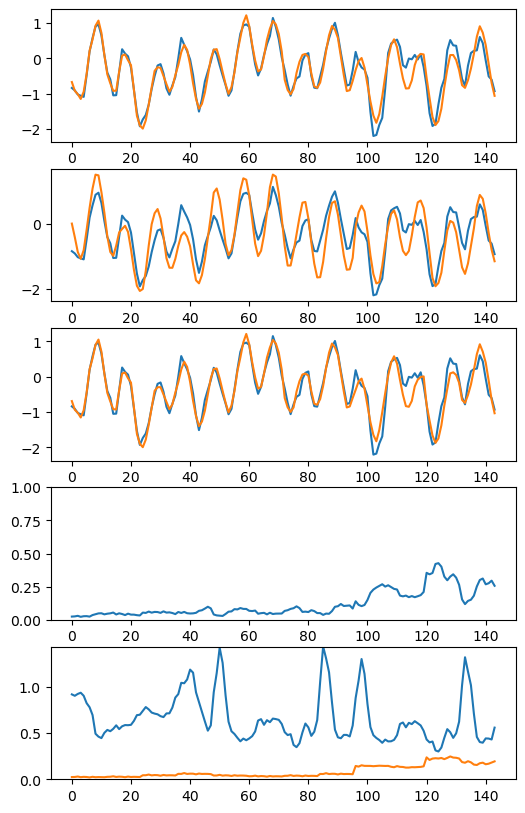

In [15]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break